# Predicting Asteroid Hazard Potential: A Machine Learning Approach
> **Queen's University** | NASA NeoWs Dataset | Binary Classification Pipeline

---

## Project Overview

This notebook implements a **full end-to-end ML pipeline** to classify Near-Earth Objects (NEOs) as **Potentially Hazardous Asteroids (PHAs)** using NASA's NeoWs dataset.

### Objectives
1. **Primary:** Build a benchmarked binary classifier for PHA screening
2. **Secondary:** Identify the most predictive orbital/physical features via feature importance analysis

### Dataset
**Source:** [NASA Asteroids Classification — Kaggle](https://www.kaggle.com/datasets/shrutimehta/nasa-asteroids-classification)

# NASA Asteroids Dataset – All 40 Columns Description

This dataset contains information about Near-Earth Objects (NEOs) obtained from NASA's NeoWS API. Below is a complete list of all columns with their descriptions, grouped by category.

## Identifiers
**`name`** :The official name or primary designation of the asteroid..
**`neo_reference_id`** : A unique reference ID for the asteroid in NASA's database.

## Physical Characteristics
**`Absolute Magnitude`**: The intrinsic brightness (H) of the asteroid. Lower values indicate larger objects. A key feature for hazard classification.

**`Est Dia in KM(min):`** Estimated minimum diameter of the asteroid in kilometers.

**`Est Dia in KM(max):`** Estimated maximum diameter of the asteroid in kilometers.

**`Est Dia in M(min):`** Estimated minimum diameter in meters.

**`Est Dia in M(max):`** Estimated maximum diameter in meters.

**`Est Dia in Miles(min):`** Estimated minimum diameter in miles.

**`Est Dia in Miles(max):`** Estimated maximum diameter in miles.

**`Est Dia in Feet(min):`** Estimated minimum diameter in feet.

**`Est Dia in Feet(max):`** Estimated maximum diameter in feet.

## Close‑Approach Data
**`Close Approach Date:`** The date of the asteroid's closest approach to Earth.

**`Epoch Date Close Approach:`** The close approach date in numeric format (e.g., milliseconds since epoch).

**`Relative Velocity km per sec`**: Relative velocity of the asteroid with respect to Earth during close approach (km/s).

**`Relative Velocity km per hr:`** Relative velocity in kilometers per hour.

**`Miles per hour:`** Relative velocity in miles per hour.

**`Miss Dist.(Astronomical):`** Miss distance from Earth in Astronomical Units (AU). 1 AU ≈ 150 million km. A critical factor in hazard classification.

**`Miss Dist.(lunar):`** Miss distance measured in lunar distances (distance from Earth to Moon ≈ 384,400 km).

**`Miss Dist.(kilometers): `**Miss distance in kilometers.

**`Miss Dist.(miles):`** Miss distance in miles.

**`Orbiting Body:`** The body the asteroid orbits (typically 'Earth' in this dataset).

## Orbital Parameters
**`Orbit ID:`** Identifier for the orbital solution used in calculations.

**`Orbit Determination Date:`** The date when the orbit was last computed or updated.

**`Orbit Uncertainity:`** Uncertainty parameter for the orbit (0–9, lower is more precise).

**`Minimum Orbit Intersection:`** The minimum distance between the asteroid's orbit and Earth's orbit (in AU). Often abbreviated as MOID. The most important feature for determining if an object is potentially hazardous.

**`Jupiter Tisserand Invariant:`** A parameter used to classify asteroids and comets based on Jupiter's gravitational influence.

**`Epoch Osculation:`** The reference date (in Julian days) for which orbital elements are defined.

**`Eccentricity:`** A measure of how elongated the orbit is (0 = circular, 1 = parabolic).

**`Semi Major Axis:`** The semi-major axis of the orbit (in AU).

**`Inclination:`** Orbital inclination relative to the ecliptic plane (degrees).

**`Asc Node Longitude:`** Longitude of the ascending node (degrees).

**`Orbital Period:`** Time required to complete one orbit around the Sun (years).

**`Perihelion Distance:`** Closest distance the asteroid gets to the Sun during its orbit (AU).

**`Perihelion Arg:`** Argument of perihelion (degrees) – defines the orientation of the orbit within its plane.

**`Aphelion Dist:`** Farthest distance the asteroid gets from the Sun (AU).

**`Perihelion Time:`** Time of perihelion passage (in days).

**`Mean Anomaly:`** Mean anomaly (degrees) – describes the position of the asteroid in its orbit at a given time.

**`Mean Motion:`** Mean angular motion (degrees per day).

**`Equinox:`** Reference equinox for the coordinate system (usually 'J2000').

##Target Variable
**`Hazardous:`** The target variable. True if the asteroid is potentially hazardous, False otherwise.

**Import Libraries**

In [1]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns
import warnings
import joblib
from sklearn.model_selection import (train_test_split, RandomizedSearchCV,StratifiedKFold, learning_curve, cross_val_predict)
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score,recall_score, f1_score, roc_auc_score,roc_curve, classification_report,confusion_matrix, ConfusionMatrixDisplay, precision_recall_curve)
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline


**Load Data**

In [2]:
df = pd.read_csv('/content/nasa.csv')
print(f'Dataset shape : {df.shape[0]:,} rows × {df.shape[1]} columns')
df

Dataset shape : 4,687 rows × 40 columns


,Neo Reference ID,Name,Absolute Magnitude,Est Dia in KM(min),Est Dia in KM(max),Est Dia in M(min),Est Dia in M(max),Est Dia in Miles(min),Est Dia in Miles(max),Est Dia in Feet(min),...,Asc Node Longitude,Orbital Period,Perihelion Distance,Perihelion Arg,Aphelion Dist,Perihelion Time,Mean Anomaly,Mean Motion,Equinox,Hazardous
0,3703080,3703080,21.600,0.127220,0.284472,127.219879,284.472297,0.079051,0.176763,417.388066,...,314.373913,609.599786,0.808259,57.257470,2.005764,2.458162e+06,264.837533,0.590551,J2000,True
1,3723955,3723955,21.300,0.146068,0.326618,146.067964,326.617897,0.090762,0.202951,479.225620,...,136.717242,425.869294,0.718200,313.091975,1.497352,2.457795e+06,173.741112,0.845330,J2000,False
2,2446862,2446862,20.300,0.231502,0.517654,231.502122,517.654482,0.143849,0.321655,759.521423,...,259.475979,643.580228,0.950791,248.415038,1.966857,2.458120e+06,292.893654,0.559371,J2000,True
3,3092506,3092506,27.400,0.008801,0.019681,8.801465,19.680675,0.005469,0.012229,28.876199,...,57.173266,514.082140,0.983902,18.707701,1.527904,2.457902e+06,68.741007,0.700277,J2000,False
4,3514799,3514799,21.600,0.127220,0.284472,127.219879,284.472297,0.079051,0.176763,417.388066,...,84.629307,495.597821,0.967687,158.263596,1.483543,2.457814e+06,135.142133,0.726395,J2000,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4682,3759007,3759007,23.900,0.044112,0.098637,44.111820,98.637028,0.027410,0.061290,144.723824,...,164.183305,457.179984,0.741558,276.395697,1.581299,2.457708e+06,304.306025,0.787436,J2000,False
4683,3759295,3759295,28.200,0.006089,0.013616,6.089126,13.615700,0.003784,0.008460,19.977449,...,345.225230,407.185767,0.996434,42.111064,1.153835,2.458088e+06,282.978786,0.884117,J2000,False
4684,3759714,3759714,22.700,0.076658,0.171412,76.657557,171.411509,0.047633,0.106510,251.501180,...,37.026468,690.054279,0.965760,274.692712,2.090708,2.458300e+06,203.501147,0.521698,J2000,False
4685,3759720,3759720,21.800,0.116026,0.259442,116.025908,259.441818,0.072095,0.161210,380.662441,...,163.802910,662.048343,1.185467,180.346090,1.787733,2.458288e+06,203.524965,0.543767,J2000,False


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4687 entries, 0 to 4686
Data columns (total 40 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Neo Reference ID              4687 non-null   int64  
 1   Name                          4687 non-null   int64  
 2   Absolute Magnitude            4687 non-null   float64
 3   Est Dia in KM(min)            4687 non-null   float64
 4   Est Dia in KM(max)            4687 non-null   float64
 5   Est Dia in M(min)             4687 non-null   float64
 6   Est Dia in M(max)             4687 non-null   float64
 7   Est Dia in Miles(min)         4687 non-null   float64
 8   Est Dia in Miles(max)         4687 non-null   float64
 9   Est Dia in Feet(min)          4687 non-null   float64
 10  Est Dia in Feet(max)          4687 non-null   float64
 11  Close Approach Date           4687 non-null   object 
 12  Epoch Date Close Approach     4687 non-null   int64  
 13  Rel

In [4]:
#descriptive statistics with color gradient for better visualizationTranspose to have features as rows bold text
df.describe().T.style.background_gradient(cmap='Blues').format(precision=3)

,count,mean,std,min,25%,50%,75%,max
Neo Reference ID,4687.000,3272297.772,548601.083,2000433.000,3097593.500,3514799.000,3690059.500,3781897.000
Name,4687.000,3272297.772,548601.083,2000433.000,3097593.500,3514799.000,3690059.500,3781897.000
Absolute Magnitude,4687.000,22.268,2.891,11.160,20.100,21.900,24.500,32.100
Est Dia in KM(min),4687.000,0.205,0.370,0.001,0.033,0.111,0.254,15.580
Est Dia in KM(max),4687.000,0.458,0.826,0.002,0.075,0.248,0.568,34.837
Est Dia in M(min),4687.000,204.604,369.573,1.011,33.462,110.804,253.837,15579.552
Est Dia in M(max),4687.000,457.509,826.391,2.260,74.824,247.765,567.597,34836.938
Est Dia in Miles(min),4687.000,0.127,0.230,0.001,0.021,0.069,0.158,9.681
Est Dia in Miles(max),4687.000,0.284,0.513,0.001,0.046,0.154,0.353,21.647
Est Dia in Feet(min),4687.000,671.274,1212.511,3.315,109.784,363.530,832.799,51114.019


In [5]:
numeric_cols_raw = [
    'Absolute Magnitude',
    'Est Dia in KM(min)', 'Est Dia in KM(max)',
    'Relative Velocity km per sec',
    'Miss Dist.(Astronomical)',
    'Eccentricity',
    'Semi Major Axis',
    'Inclination',
    'Orbital Period',
    'Perihelion Distance',
    'Minimum Orbit Intersection',
    'Orbit Uncertainity',
    'Jupiter Tisserand Invariant'
]


#Plot feature distributions for Hazardous vs Non-Hazardous asteroids


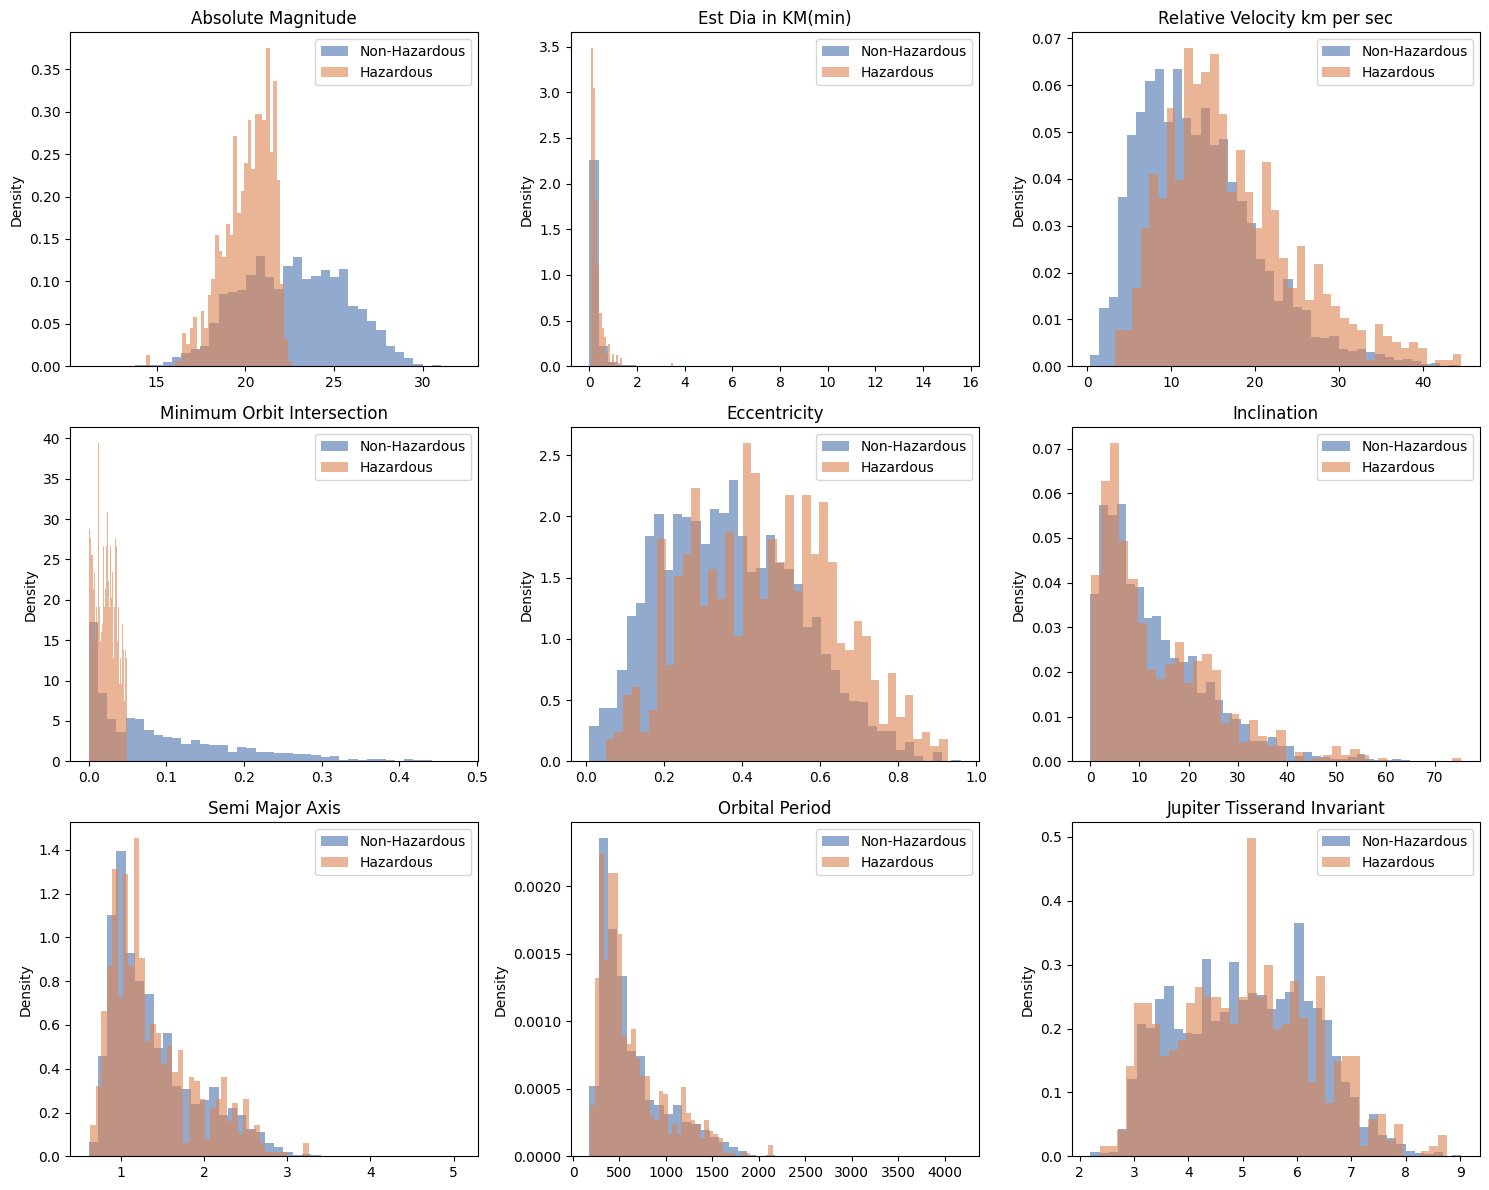

In [6]:

features = ['Absolute Magnitude', 'Est Dia in KM(min)', 'Relative Velocity km per sec',
            'Minimum Orbit Intersection', 'Eccentricity', 'Inclination',
            'Semi Major Axis', 'Orbital Period', 'Jupiter Tisserand Invariant']

rows = (len(features) + 2) // 3
fig, axes = plt.subplots(rows, 3, figsize=(15, 4 * rows))
axes = axes.flatten()

# Drow every feature
for i, feat in enumerate(features):
    ax = axes[i]
    # Hazardous = False (0)
    ax.hist(df[df['Hazardous'] == 0][feat], bins=40, alpha=0.6,label='Non‑Hazardous', color='#4C72B0', density=True)
    # Hazardous = True (1)
    ax.hist(df[df['Hazardous'] == 1][feat], bins=40, alpha=0.6,label='Hazardous', color='#DD8452', density=True)
    ax.set_title(feat)
    ax.set_ylabel('Density')
    ax.legend()

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

# Create box plots for each numerical column to visualize outliers


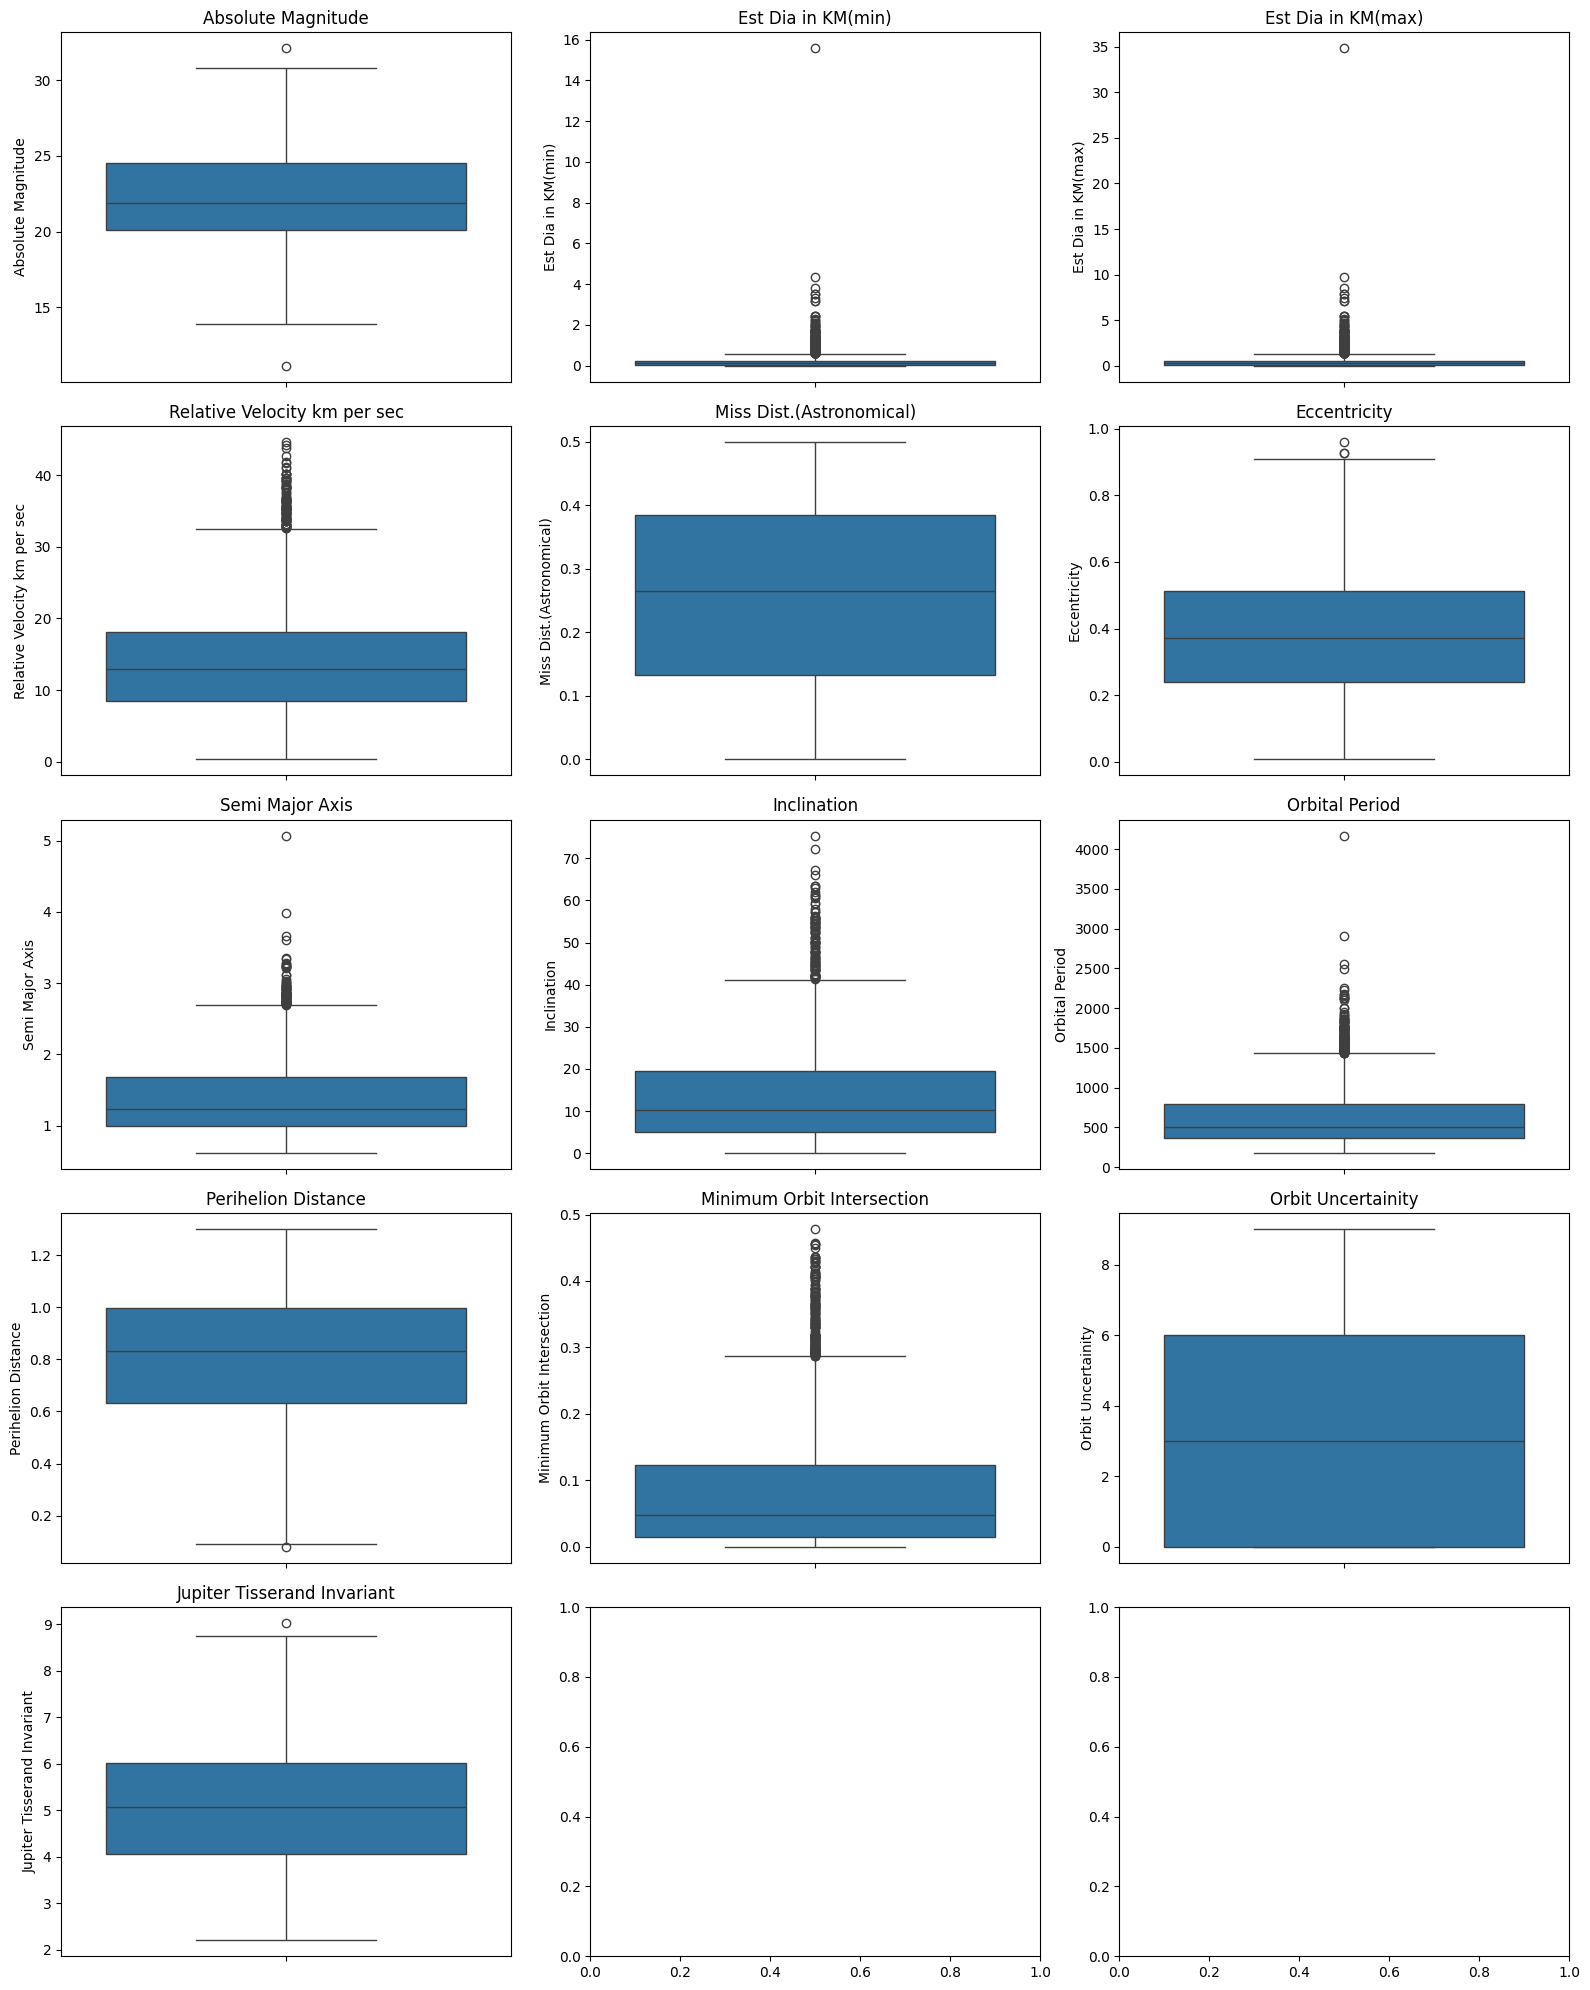

In [7]:
fig, axes = plt.subplots(5, 3, figsize=(16, 20))
axes = axes.flatten()
for i, col in enumerate(numeric_cols_raw):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

#Hazardous Target Distribution – Class Imbalance Visualization


Hazardous
False    3932
True      755
Name: count, dtype: int64
Hazardous
False    83.891615
True     16.108385
Name: proportion, dtype: float64


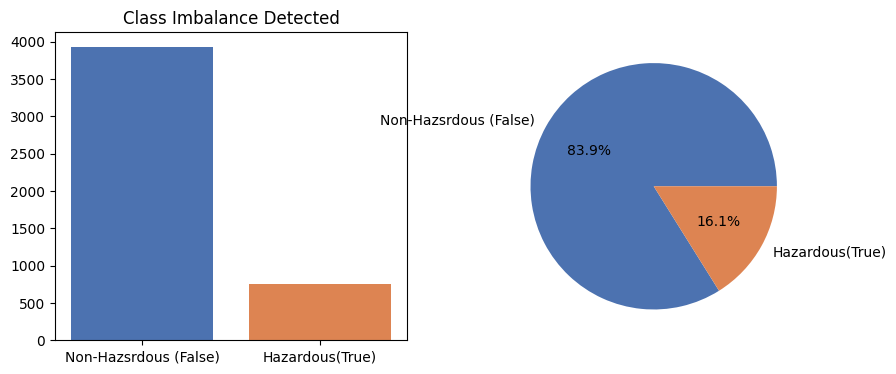

In [8]:
# Check target variable distribution: count and percentage of hazardous vs non-hazardous asteroids
counts = df['Hazardous'].value_counts()
pcts = df['Hazardous'].value_counts(normalize=True) * 100
print(counts)
print(pcts)

# Visualize the imbalance using bar and pie charts
fig, ax = plt.subplots(1,2, figsize=(10,4))
ax[0].bar(['Non-Hazsrdous (False)','Hazardous(True)'], counts.values, color=['#4C72B0','#DD8452'])
ax[0].set_title('Class Imbalance Detected')
ax[1].pie(counts.values, labels=['Non-Hazsrdous (False)','Hazardous(True)'], autopct='%1.1f%%', colors=['#4C72B0','#DD8452'])
plt.show()

#Boxplots of all numerical features grouped by Hazardous class

/tmp/ipykernel_34356/282654126.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Hazardous', y=col, data=df, palette=['green', 'red'], ax=axes[i])
/tmp/ipykernel_34356/282654126.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(['Non-hazardous', 'Hazardous'])
/tmp/ipykernel_34356/282654126.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Hazardous', y=col, data=df, palette=['green', 'red'], ax=axes[i])
/tmp/ipykernel_34356/282654126.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax

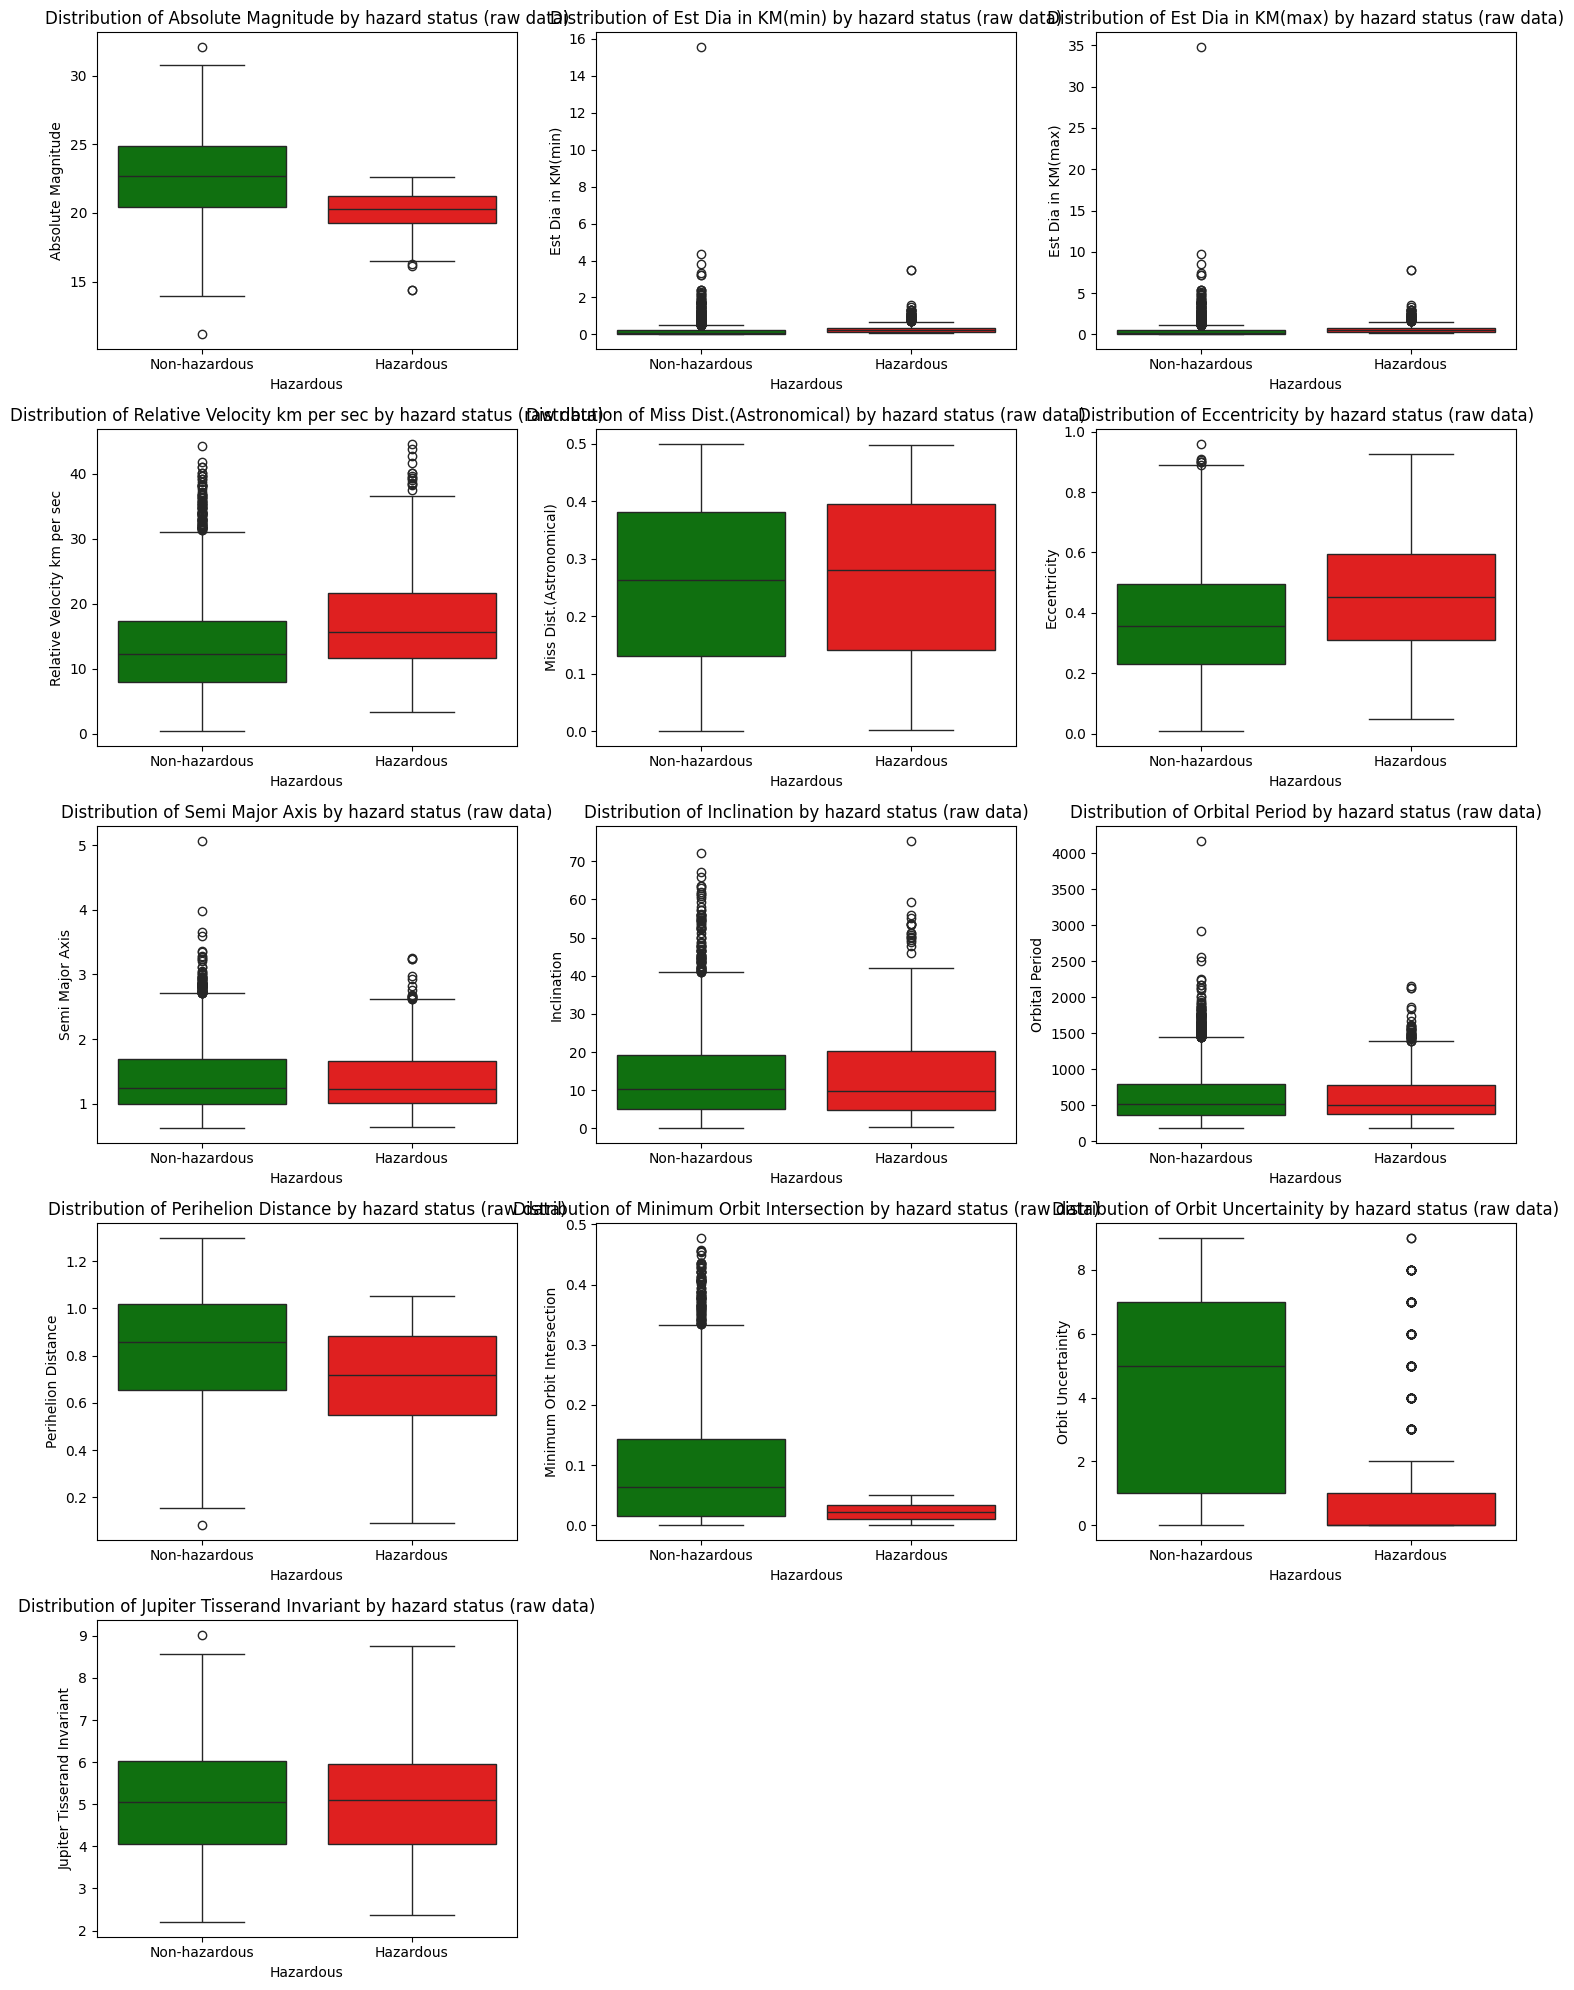

In [9]:
n_cols = 3
n_rows = math.ceil(len(numeric_cols_raw) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(numeric_cols_raw):
    sns.boxplot(x='Hazardous', y=col, data=df, palette=['green', 'red'], ax=axes[i])
    axes[i].set_title(f'Distribution of {col} by hazard status (raw data)')
    axes[i].set_xticklabels(['Non-hazardous', 'Hazardous'])

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# Correlation heatmap of raw numerical features


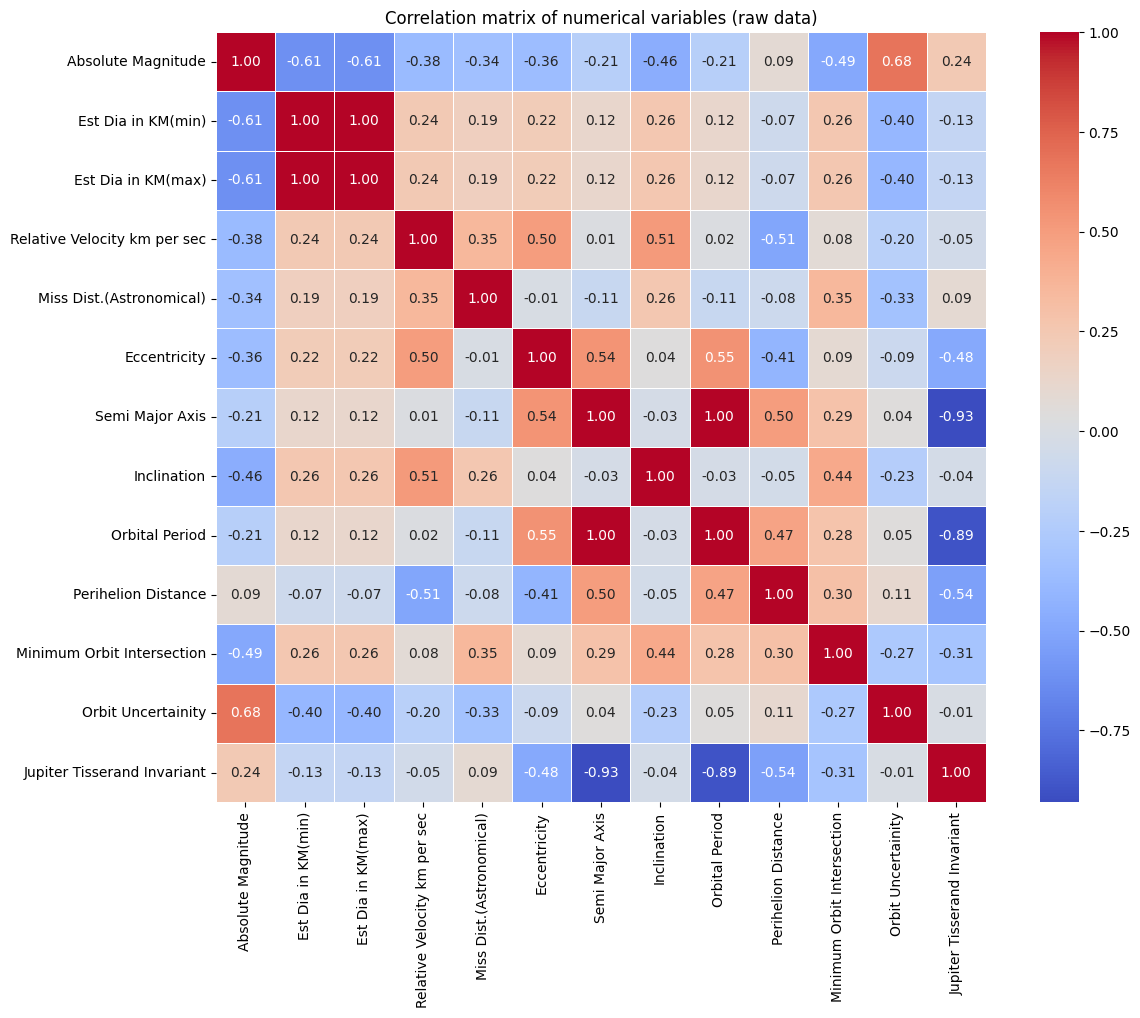

In [10]:
# Compute and visualize correlation matrix for raw numerical features
corr = df[numeric_cols_raw].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True, linewidths=0.5)
plt.title('Correlation matrix of numerical variables (raw data)')
plt.show()

#Missing Values

In [11]:
df.isnull().sum()

,0
Neo Reference ID,0
Name,0
Absolute Magnitude,0
Est Dia in KM(min),0
Est Dia in KM(max),0
Est Dia in M(min),0
Est Dia in M(max),0
Est Dia in Miles(min),0
Est Dia in Miles(max),0
Est Dia in Feet(min),0


In [12]:
df.isnull().sum().any()

np.False_

#Scatter Plot: MOID vs Absolute Magnitude – NASA PHA Criteria


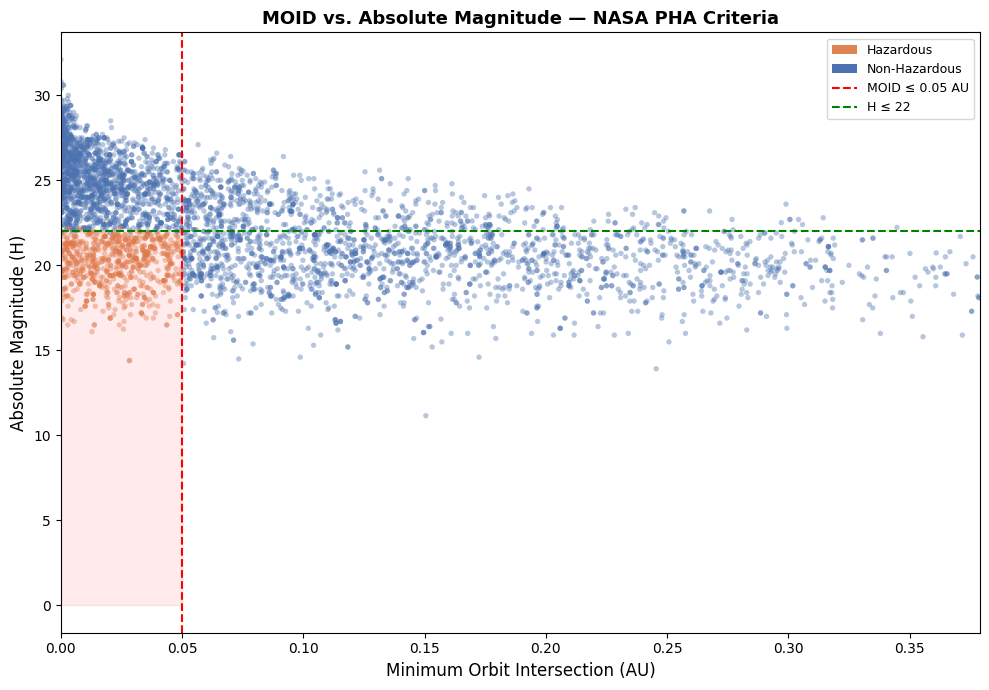

In [13]:
# Prepare data by dropping rows with missing values in key columns
plot_df = df.dropna(subset=['Hazardous', 'Minimum Orbit Intersection', 'Absolute Magnitude']).copy()

colors = plot_df['Hazardous'].map({False: '#4C72B0', True: '#DD8452'})

fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(plot_df['Minimum Orbit Intersection'], plot_df['Absolute Magnitude'],
           c=colors, alpha=0.4, s=15, edgecolors='none')

# Create scatter plot: MOID vs Absolute Magnitude
ax.axvline(0.05, color='red', linestyle='--', linewidth=1.5, label='MOID ≤ 0.05 AU')
ax.axhline(22, color='green', linestyle='--', linewidth=1.5, label='H ≤ 22')
ax.fill_betweenx([0, 22], 0, 0.05, alpha=0.08, color='red', label='NASA PHA Zone')

ax.legend(handles=[
    Patch(facecolor='#DD8452', label='Hazardous'),
    Patch(facecolor='#4C72B0', label='Non-Hazardous'),
    *ax.get_legend_handles_labels()[0][:2]
], loc='upper right', fontsize=9)

ax.set_xlim(0, plot_df['Minimum Orbit Intersection'].quantile(0.99))
ax.set_xlabel('Minimum Orbit Intersection (AU)', fontsize=12)
ax.set_ylabel('Absolute Magnitude (H)', fontsize=12)
ax.set_title('MOID vs. Absolute Magnitude — NASA PHA Criteria', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

#Sanity Check — NASA PHA Rule-Based Baseline
### In order to avoid target leakage and trivial learning, we intentionally removed the 'MOID' and 'Absolute Magnitude' columns before training the models. Because the target variable 'Hazardous' is explicitly calculated from these two attributes, the models would just memorize the definitional rule instead of learning hidden, generalizable patterns in other physical and orbital characteristics if we included them.

In [14]:
# Apply NASA PHA rule directly: MOID < 0.05 AU AND Absolute Magnitude < 22
NASA_y_check = df['Hazardous'].map({True: 1, False: 0}).fillna(0).astype(int)
rule_preds = ((df['Minimum Orbit Intersection'] < 0.05) & (df['Absolute Magnitude'] < 22)).astype(int)

print('Sanity Check — Rule-Based Baseline (NASA PHA Definition)')
print('-' * 55)
print(f'Accuracy : {accuracy_score(NASA_y_check, rule_preds):.4f}')
print(f'Precision: {precision_score(NASA_y_check, rule_preds):.4f}')
print(f'Recall : {recall_score(NASA_y_check, rule_preds):.4f}')
print(f'F1 : {f1_score(NASA_y_check, rule_preds):.4f}')
print('-' * 25)
print('NOTE: Models scoring near the above have learned the label definition,')
print('not a generalizable pattern. Absolute Magnitude & MOID will be dropped.')

Sanity Check — Rule-Based Baseline (NASA PHA Definition)
-------------------------------------------------------
Accuracy : 0.9953
Precision: 0.9986
Recall : 0.9722
F1 : 0.9852
-------------------------
NOTE: Models scoring near the above have learned the label definition,
not a generalizable pattern. Absolute Magnitude & MOID will be dropped.


#Data Cleaning

In [15]:
lenght_column = len(df.columns)
print("the lenght of columns : ",lenght_column)

the lenght of columns :  40


In [16]:
duplicated_rows = df.duplicated()
print("number of repeated rows", duplicated_rows.sum())

number of repeated rows 0


In [17]:
df['Est Dia in KM(avg)'] = (df['Est Dia in KM(min)'] + df['Est Dia in KM(max)']) / 2

In [18]:
cols_to_drop = [
    'Neo Reference ID', 'Name',
    'Close Approach Date', 'Orbit Determination Date',
    'Est Dia in M(min)', 'Est Dia in M(max)',
    'Est Dia in Miles(min)', 'Est Dia in Miles(max)',
    'Est Dia in Feet(min)', 'Est Dia in Feet(max)',
    'Relative Velocity km per hr', 'Miles per hour',
    'Miss Dist.(lunar)', 'Miss Dist.(kilometers)', 'Miss Dist.(miles)',
    'Orbiting Body', 'Equinox',
    'Epoch Date Close Approach', 'Epoch Osculation', 'Perihelion Time',
    'Absolute Magnitude','Minimum Orbit Intersection',
    'Est Dia in KM(max)', 'Orbital Period']

df.drop(columns=cols_to_drop, inplace=True)
print('number of coulmns after droping: ',len(df.columns))


number of coulmns after droping:  17


In [19]:
# Convert Hazardous from boolean/string to integer (1 = Hazardous, 0 = Non-Hazardous)
df['Hazardous'] = df['Hazardous'].map({True: 1, False: 0})
df = df.dropna(subset=['Hazardous'])

df['Hazardous'] = df['Hazardous'].astype(int)

print(df['Hazardous'].value_counts())
print(df['Hazardous'].dtype)

Hazardous
0    3932
1     755
Name: count, dtype: int64
int64


In [20]:
print(df['Hazardous'].value_counts())
print(df['Hazardous'].dtype)
print(df['Hazardous'].head(10))

Hazardous
0    3932
1     755
Name: count, dtype: int64
int64
0    1
1    0
2    1
3    0
4    1
5    0
6    0
7    0
8    0
9    1
Name: Hazardous, dtype: int64


#Feature Engineering

In [21]:
EPS   = 1e-8
d_mn  = df['Est Dia in KM(min)']
v     = df['Relative Velocity km per sec']
md_au = df['Miss Dist.(Astronomical)']
ecc   = df['Eccentricity']
sma   = df['Semi Major Axis']
peri  = df['Perihelion Distance']

# Kinetic Energy Index — KE proportional to v^2 * mass, mass proportional to d^3
df['FE_kinetic_energy_idx'] = v**2 * (d_mn**3)

# Orbit elongation relative to orbit size — how stretched the orbit is
df['FE_orbit_stretch'] = ecc / (sma + EPS)

# Perihelion * Eccentricity — close-to-Sun + elongated orbit combined risk
df['FE_peri_x_ecc'] = peri * ecc

# Velocity * actual flyby miss distance (close-approach distance, NOT MOID)
df['FE_vel_x_miss'] = v * md_au

# Aphelion estimate — max distance from Sun derived from orbital geometry only
df['FE_aphelion_est'] = sma * (1 + ecc)

NEW_FEATURES = [
    'FE_kinetic_energy_idx', 'FE_orbit_stretch','Est Dia in KM(avg)'
    ,'FE_peri_x_ecc', 'FE_vel_x_miss', 'FE_aphelion_est'
]

print(f'{len(NEW_FEATURES)} engineered features added.')
df[NEW_FEATURES].describe().round(3)


6 engineered features added.


,FE_kinetic_energy_idx,FE_orbit_stretch,Est Dia in KM(avg),FE_peri_x_ecc,FE_vel_x_miss,FE_aphelion_est
count,4687.000,4687.000,4687.000,4687.000,4687.000,4687.000
mean,100.502,0.287,0.331,0.293,3.961,1.987
std,1467.841,0.147,0.598,0.149,3.547,0.952
min,0.000,0.007,0.002,0.008,0.002,0.804
25%,0.004,0.196,0.054,0.183,1.146,1.266
50%,0.161,0.252,0.179,0.248,2.977,1.618
75%,3.715,0.351,0.411,0.388,5.869,2.451
max,73619.700,1.072,25.208,0.895,21.803,8.984


/tmp/ipykernel_34356/1786101260.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Hazardous', y=feat, data=df,palette=['#4C72B0','#DD8452'], ax=axes[i], showfliers=False)
/tmp/ipykernel_34356/1786101260.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(['Non-Haz', 'Hazardous'], fontsize=9)
/tmp/ipykernel_34356/1786101260.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Hazardous', y=feat, data=df,palette=['#4C72B0','#DD8452'], ax=axes[i], showfliers=False)
/tmp/ipykernel_34356/1786101260.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks

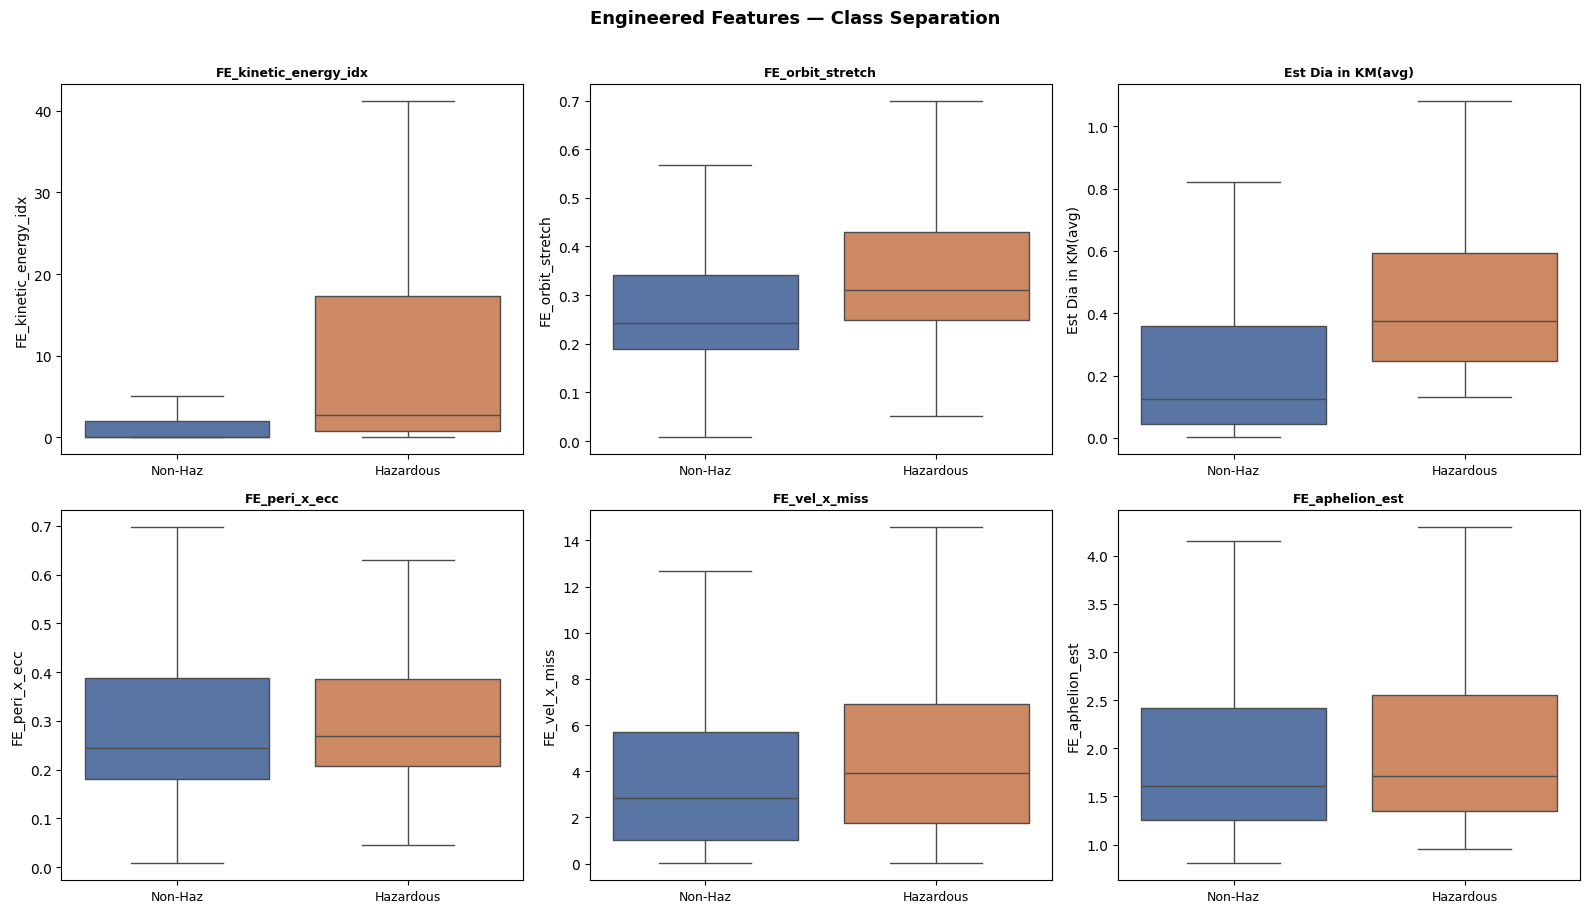

In [22]:
# Boxplots of engineered features showing distribution by Hazardous class
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, feat in enumerate(NEW_FEATURES):
    sns.boxplot(x='Hazardous', y=feat, data=df,palette=['#4C72B0','#DD8452'], ax=axes[i], showfliers=False)
    axes[i].set_title(feat, fontsize=9, fontweight='bold')
    axes[i].set_xticklabels(['Non-Haz', 'Hazardous'], fontsize=9)
    axes[i].set_xlabel('')

plt.suptitle('Engineered Features — Class Separation',fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [23]:
lenght_of_nem_columns = len(df.columns)
print("the lenght of columns after engineering: ",lenght_of_nem_columns)

the lenght of columns after engineering:  22


#Spilt Data

In [24]:
X = df.drop(columns=['Hazardous'])
y = df['Hazardous']
X.shape, y.shape

((4687, 21), (4687,))

In [25]:
from sklearn.model_selection import train_test_split

#spilt train-> 70% ,total_test-> 30%
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
#spilt total_test ->(actual test = 15% , validation = 15%)
X_val, X_test, y_val, y_test = train_test_split( X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

In [26]:
total = len(X)
print('Total dataset  : ',total)
print('Train          : ',len(X_train))
print('Validation     : ',len(X_val))
print('Test           : ',len(X_test))

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

Total dataset  :  4687
Train          :  3280
Validation     :  703
Test           :  704
Train: (3280, 21), Val: (703, 21), Test: (704, 21)


# MODEL TRAINING & EVALUATION FUNCTION

### Purpose : This section defines the core training pipeline used across all models. Train a model using RandomizedSearchCV with 5‑fold stratified CVoptimize for recall, evaluate on train/validation/test sets,detect overfitting (gap > 0.05), and store all results for later analysis.

In [27]:
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
all_results = []
trained_models = {}

In [28]:
# evaluate models
def evaluate_splits(model):
    splits  = {'Train': (X_train, y_train), 'Val': (X_val, y_val), 'Test': (X_test, y_test)}
    results = {}
    for name, (X, y) in splits.items():
        preds = model.predict(X)
        probs = model.predict_proba(X)[:, 1]
        results[name] = {'Accuracy':  accuracy_score(y, preds),
                         'Precision': precision_score(y, preds, zero_division=0),
                         'Recall': recall_score(y, preds),
                         'F1': f1_score(y, preds),
                         'AUC': roc_auc_score(y, probs),
                         'preds': preds,
                         'probs': probs}
    return results

In [29]:
# print results
def print_results(results):
    print(f'\n{"Split":<10} {"Accuracy":>10} {"Precision":>10} {"Recall":>10} {"F1":>10} {"AUC":>10}')
    print('-' * 55)

    for split in ['Train', 'Val', 'Test']:
        r = results[split]
        print(f'{split:<10} {r["Accuracy"]:>10.4f} {r["Precision"]:>10.4f} '
              f'{r["Recall"]:>10.4f} {r["F1"]:>10.4f} {r["AUC"]:>10.4f}')

    gap_val  = results['Train']['Recall'] - results['Val']['Recall']
    gap_test = results['Train']['Recall'] - results['Test']['Recall']
    status   = 'Possible Overfit' if gap_val > 0.05 else 'OK'

    print(f'\nRecall Gap (Train - Val)  : {gap_val:.4f} --> {status}')
    print(f'Recall Gap (Train - Test) : {gap_test:.4f}')
    print(classification_report(y_test, results['Test']['preds'], target_names=['Non-Hazardous', 'Hazardous']))

In [30]:
# main function
def train_evaluate(name, pipeline, param_dist, n_iter=20):
    print(f'\nModel: {name}')
    print('-' * 40)

    # search for best hyperparameters
    search = RandomizedSearchCV(pipeline, param_dist, n_iter=n_iter,cv=CV, scoring='recall', n_jobs=-1, random_state=42)
    search.fit(X_train, y_train)
    best_model = search.best_estimator_

    print(f'Best CV Recall : {search.best_score_:.4f}')
    print(f'Best Params    : {search.best_params_}')

    results = evaluate_splits(best_model)
    print_results(results)

    # save results
    gap_val = results['Train']['Recall'] - results['Val']['Recall']
    res = {'Model': name,
           'Accuracy': results['Test']['Accuracy'],
           'Precision': results['Test']['Precision'],
           'Recall': results['Test']['Recall'],
           'F1': results['Test']['F1'],
           'AUC': results['Test']['AUC'],
           'Train_Recall': results['Train']['Recall'],
           'Val_Recall': results['Val']['Recall'],
           'Gap_Val': gap_val,
           'preds': results['Test']['preds'],
           'probs': results['Test']['probs']}

    all_results.append(res)
    trained_models[name] = {'model': best_model, 'preds': res['preds'], 'probs': res['probs']}

    return best_model, res

#Logistic Regression

In [31]:
# Logistic Regression
pipe_lr = ImbPipeline([('scaler', StandardScaler()),
                       ('smote', SMOTE(random_state=42)),
                       ('clf', LogisticRegression(max_iter=2000, random_state=42))])

params_lr = {'smote__k_neighbors': [3,5,7],
             'clf__C': [0.001,0.01,0.1,1,10,100],
             'clf__class_weight': ['balanced', None]}

best_lr, res_lr = train_evaluate('Logistic Regression', pipe_lr, params_lr, n_iter=15)


Model: Logistic Regression
----------------------------------------
Best CV Recall : 0.7915
Best Params    : {'smote__k_neighbors': 3, 'clf__class_weight': None, 'clf__C': 0.01}

Split        Accuracy  Precision     Recall         F1        AUC
-------------------------------------------------------
Train          0.7381     0.3582     0.7917     0.4932     0.8329
Val            0.7312     0.3538     0.8142     0.4933     0.8247
Test           0.7102     0.3295     0.7632     0.4603     0.8192

Recall Gap (Train - Val)  : -0.0225 --> OK
Recall Gap (Train - Test) : 0.0285
               precision    recall  f1-score   support

Non-Hazardous       0.94      0.70      0.80       590
    Hazardous       0.33      0.76      0.46       114

     accuracy                           0.71       704
    macro avg       0.63      0.73      0.63       704
 weighted avg       0.84      0.71      0.75       704



#SVM

In [32]:
pipe_svm = ImbPipeline([('scaler', StandardScaler()),
                        ('smote', SMOTE(random_state=42)),
                        ('clf', SVC(probability=True, random_state=42))])

params_svm = {'smote__k_neighbors': [3,5,7],
              'clf__C': [0.1,1,10,50],
              'clf__gamma': ['scale','auto',0.01,0.001],
              'clf__kernel': ['rbf','sigmoid'],
              'clf__class_weight': ['balanced', None]}

best_svm, res_svm = train_evaluate('SVM', pipe_svm, params_svm, n_iter=15)


Model: SVM
----------------------------------------
Best CV Recall : 0.8541
Best Params    : {'smote__k_neighbors': 3, 'clf__kernel': 'rbf', 'clf__gamma': 0.001, 'clf__class_weight': 'balanced', 'clf__C': 1}

Split        Accuracy  Precision     Recall         F1        AUC
-------------------------------------------------------
Train          0.6866     0.3219     0.8561     0.4679     0.8338
Val            0.6828     0.3179     0.8496     0.4627     0.8228
Test           0.6548     0.2978     0.8333     0.4388     0.8098

Recall Gap (Train - Val)  : 0.0065 --> OK
Recall Gap (Train - Test) : 0.0227
               precision    recall  f1-score   support

Non-Hazardous       0.95      0.62      0.75       590
    Hazardous       0.30      0.83      0.44       114

     accuracy                           0.65       704
    macro avg       0.62      0.73      0.59       704
 weighted avg       0.84      0.65      0.70       704



#Random Forest

In [33]:
pipe_rf = ImbPipeline([('scaler', StandardScaler()),
                       ('smote', SMOTE(random_state=42)),
                       ('clf', RandomForestClassifier(random_state=42, n_jobs=-1))])

params_rf = {'smote__k_neighbors': [3,5,7],
             'clf__n_estimators': [100,200,300],
             'clf__max_depth': [5,10,15,20],
             'clf__min_samples_split': [10,20,30],
             'clf__min_samples_leaf': [4,8,16],
             'clf__max_features': ['sqrt','log2'],
             'clf__class_weight': ['balanced', None]}

best_rf, res_rf = train_evaluate('Random Forest', pipe_rf, params_rf, n_iter=15)


Model: Random Forest
----------------------------------------
Best CV Recall : 0.9375
Best Params    : {'smote__k_neighbors': 5, 'clf__n_estimators': 300, 'clf__min_samples_split': 10, 'clf__min_samples_leaf': 4, 'clf__max_features': 'log2', 'clf__max_depth': 5, 'clf__class_weight': None}

Split        Accuracy  Precision     Recall         F1        AUC
-------------------------------------------------------
Train          0.7884     0.4308     0.9792     0.5984     0.9438
Val            0.7738     0.4115     0.9469     0.5737     0.9201
Test           0.7514     0.3907     0.9561     0.5547     0.9058

Recall Gap (Train - Val)  : 0.0323 --> OK
Recall Gap (Train - Test) : 0.0230
               precision    recall  f1-score   support

Non-Hazardous       0.99      0.71      0.83       590
    Hazardous       0.39      0.96      0.55       114

     accuracy                           0.75       704
    macro avg       0.69      0.83      0.69       704
 weighted avg       0.89      0.7

#XGBoost

In [34]:
# Non-Hazardous (0) is much larger than Hazardous (1) so we compute this ratio to pass it as scale_pos_weight to the model
spw = len(y_train[y_train==0]) / len(y_train[y_train==1])

pipe_xgb = ImbPipeline([('scaler', StandardScaler()),
                        ('smote', SMOTE(random_state=42)),
                        ('clf', XGBClassifier(random_state=42, eval_metric='logloss', n_jobs=-1))])

params_xgb = {'smote__k_neighbors': [3,5,7],
              'clf__n_estimators': [100,200,300],
              'clf__max_depth': [3,4,5],
              'clf__learning_rate': [0.01,0.05,0.1],
              'clf__subsample': [0.6,0.7,0.8],
              'clf__colsample_bytree': [0.6,0.7,0.8],
              'clf__reg_alpha': [0.1,0.5,1],
              'clf__reg_lambda': [1,2,5],
              'clf__scale_pos_weight': [1, spw, spw*1.5]}

best_xgb, res_xgb = train_evaluate('XGBoost', pipe_xgb, params_xgb, n_iter=15)


Model: XGBoost
----------------------------------------
Best CV Recall : 0.9981
Best Params    : {'smote__k_neighbors': 7, 'clf__subsample': 0.7, 'clf__scale_pos_weight': 7.818181818181818, 'clf__reg_lambda': 2, 'clf__reg_alpha': 0.5, 'clf__n_estimators': 100, 'clf__max_depth': 4, 'clf__learning_rate': 0.01, 'clf__colsample_bytree': 0.6}

Split        Accuracy  Precision     Recall         F1        AUC
-------------------------------------------------------
Train          0.7216     0.3664     1.0000     0.5363     0.9337
Val            0.7226     0.3669     1.0000     0.5368     0.9183
Test           0.6932     0.3455     1.0000     0.5135     0.8984

Recall Gap (Train - Val)  : 0.0000 --> OK
Recall Gap (Train - Test) : 0.0000
               precision    recall  f1-score   support

Non-Hazardous       1.00      0.63      0.78       590
    Hazardous       0.35      1.00      0.51       114

     accuracy                           0.69       704
    macro avg       0.67      0.82    

In [35]:
# collect results in DataFrame
results = [res_lr, res_rf, res_xgb, res_svm]
results_df = pd.DataFrame(results)
results_df.set_index('Model', inplace=True)
results_df

,Accuracy,Precision,Recall,F1,AUC,Train_Recall,Val_Recall,Gap_Val,preds,probs
Model,,,,,,,,,,
Logistic Regression,0.710227,0.329545,0.763158,0.460317,0.819224,0.791667,0.814159,-0.022493,"[0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, ...","[0.22316457286694436, 0.09077501957560274, 0.0..."
Random Forest,0.751420,0.390681,0.956140,0.554707,0.905828,0.979167,0.946903,0.032264,"[0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.013282900897232294, 0.004082718542883408, 0..."
XGBoost,0.693182,0.345455,1.000000,0.513514,0.898424,1.000000,1.000000,0.000000,"[0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, ...","[0.32125282, 0.30480662, 0.2964599, 0.92291033..."
SVM,0.654830,0.297806,0.833333,0.438799,0.809850,0.856061,0.849558,0.006503,"[0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, ...","[0.15052784529605034, 0.05779516799186131, 0.0..."


#Overfitting Analysis Dashboard:
###Compare Train, Validation, and Test Recall across models

OVERFITTING ANALYSIS DASHBOARD
 Model                        Train      Val     Test   Gap(T-V)  Status
  Logistic Regression         0.7917   0.8142   0.7632    -0.0225  OK
  Random Forest               0.9792   0.9469   0.9561     0.0323  OK
  XGBoost                     1.0000   1.0000   1.0000     0.0000  OK
  SVM                         0.8561   0.8496   0.8333     0.0065  OK


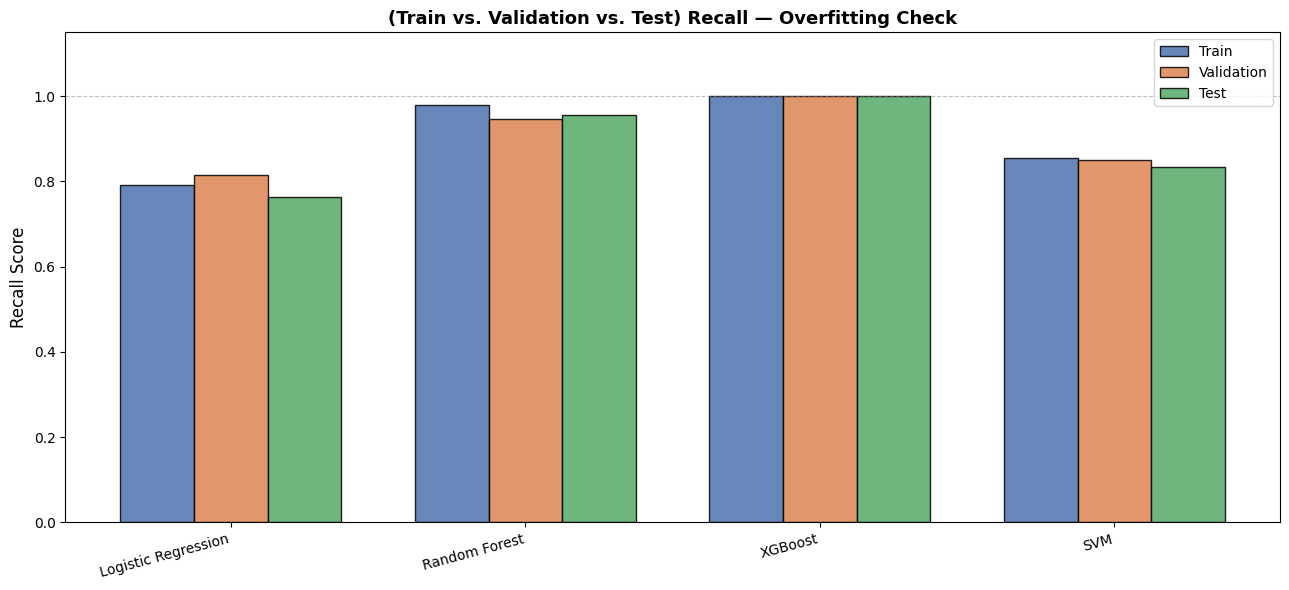

In [36]:
print('OVERFITTING ANALYSIS DASHBOARD')
print('='*75)
print(f' {"Model":<25} {"Train":>8} {"Val":>8} {"Test":>8} {"Gap(T-V)":>10}  Status')

# check if there are overfitting or not (gap > 0.05)
for idx, row in results_df.iterrows():
    gap = row['Gap_Val']
    status = 'OVERFIT' if gap > 0.05 else 'OK'
    print(f'  {idx:<25} {row["Train_Recall"]:>8.4f} 'f'{row["Val_Recall"]:>8.4f} {row["Recall"]:>8.4f} 'f'{gap:>10.4f}  {status}')

# Prepare data for bar chart
models = results_df.index.tolist()
t_rec = results_df['Train_Recall'].tolist()
v_rec = results_df['Val_Recall'].tolist()
te_rec = results_df['Recall'].tolist()

x = np.arange(len(models))
width = 0.25

# Create bar chart comparing recall across train, validation, and test sets
fig, ax = plt.subplots(figsize=(13, 6))
ax.bar(x - width, t_rec, width, label='Train', color='#4C72B0', edgecolor='black', alpha=0.85)
ax.bar(x, v_rec, width, label='Validation', color='#DD8452', edgecolor='black', alpha=0.85)
ax.bar(x + width, te_rec, width, label='Test', color='#55A868', edgecolor='black', alpha=0.85)

# format chart axes, labels, title, and display
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=15, ha='right', fontsize=10)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Recall Score', fontsize=12)
ax.set_title('(Train vs. Validation vs. Test) Recall — Overfitting Check',fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.axhline(1.0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
plt.tight_layout()
plt.show()

#Learning Curves

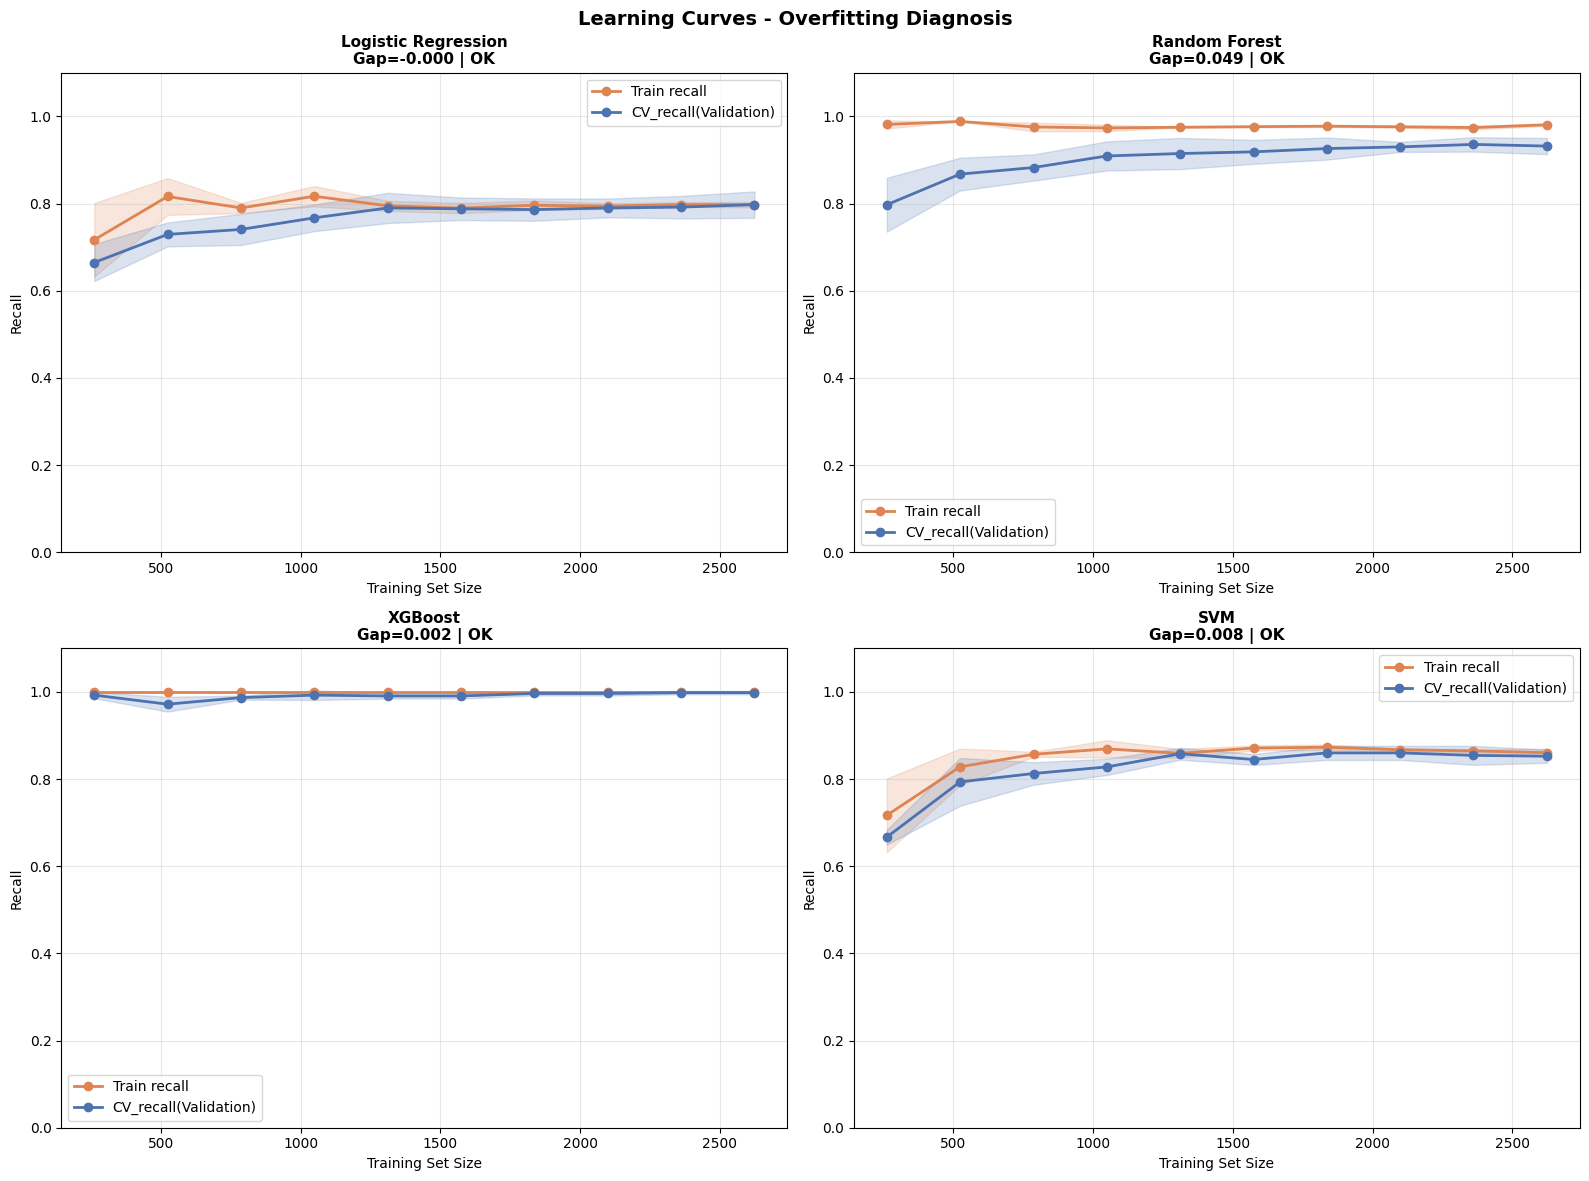

In [37]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

models = {'Logistic Regression': best_lr,'Random Forest': best_rf,'XGBoost': best_xgb,'SVM': best_svm}

for i, (name, model) in enumerate(models.items()):
    train_sizes, train_scores, val_scores = learning_curve(model, X_train, y_train,
                                                           cv=5, scoring='recall',
                                                           train_sizes=np.linspace(0.1, 1.0, 10),
                                                           n_jobs=-1)

    t_mean = train_scores.mean(axis=1)
    t_std  = train_scores.std(axis=1)
    v_mean = val_scores.mean(axis=1)
    v_std  = val_scores.std(axis=1)

    ax = axes[i]
    ax.plot(train_sizes, t_mean, 'o-', label='Train recall', color='#DD8452', lw=2)
    ax.plot(train_sizes, v_mean, 'o-', label='CV_recall(Validation)', color='#4C72B0', lw=2)
    ax.fill_between(train_sizes, t_mean - t_std, t_mean + t_std, alpha=0.2, color='#DD8452')
    ax.fill_between(train_sizes, v_mean - v_std, v_mean + v_std, alpha=0.2, color='#4C72B0')

    gap = t_mean[-1] - v_mean[-1]
    status = 'Overfit' if gap > 0.05 else 'OK'
    ax.set_title(f'{name}\nGap={gap:.3f} | {status}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Training Set Size')
    ax.set_ylabel('Recall')
    ax.set_ylim(0, 1.1)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Learning Curves - Overfitting Diagnosis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

#Soft Voting

In [38]:
# Average predicted probabilities across all models
models = [best_lr, best_rf, best_xgb, best_svm]

#soft voting function
def soft_vote(models, X):
    probs = np.mean([m.predict_proba(X)[:,1] for m in models], axis=0)
    return (probs >= 0.5).astype(int), probs

y_train_pred_vote, _ = soft_vote(models, X_train)
y_val_pred_vote, _ = soft_vote(models, X_val)
y_test_pred_vote, y_test_proba_vote = soft_vote(models, X_test)

vote_train_rec = recall_score(y_train, y_train_pred_vote)
vote_val_rec = recall_score(y_val, y_val_pred_vote)
vote_test_rec = recall_score(y_test, y_test_pred_vote)
vote_auc = roc_auc_score(y_test, y_test_proba_vote)

print("Voting - Train rec:", vote_train_rec, "Val rec:", vote_val_rec, "Test rec:", vote_test_rec)
print("AUC:", vote_auc)

results_df.loc['Voting'] = [accuracy_score(y_test, y_test_pred_vote),
                            precision_score(y_test, y_test_pred_vote),
                            vote_test_rec,
                            f1_score(y_test, y_test_pred_vote),
                            vote_auc,
                            vote_train_rec,
                            vote_val_rec,
                            vote_train_rec - vote_val_rec,
                            y_test_proba_vote,
                            y_test_pred_vote]


Voting - Train rec: 0.9488636363636364 Val rec: 0.9203539823008849 Test rec: 0.956140350877193
AUC: 0.8753047873922093


#Stacking Ensemble
### - Stacking with logistic regression meta-learner
### - OOF predictions: meta-learner trains on out-of-fold probabilities

In [39]:
# Step 1: OOF predictions on X_train (each sample predicted by a fold that never saw it)
oof_preds = []
for m in models:
    oof = cross_val_predict(m, X_train, y_train, cv=5, method='predict_proba', n_jobs=-1)[:, 1]
    oof_preds.append(oof)
X_meta_train = np.column_stack(oof_preds)

# Step 2: base models (trained on full X_train) predict on val and test as usual
X_meta_val  = np.column_stack([m.predict_proba(X_val)[:,1]  for m in models])
X_meta_test = np.column_stack([m.predict_proba(X_test)[:,1] for m in models])

meta = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
meta.fit(X_meta_train, y_train)

y_train_pred_stack = meta.predict(X_meta_train)
y_val_pred_stack   = meta.predict(X_meta_val)
y_test_pred_stack  = meta.predict(X_meta_test)
y_test_proba_stack = meta.predict_proba(X_meta_test)[:,1]

stack_train_rec = recall_score(y_train, y_train_pred_stack)
stack_val_rec   = recall_score(y_val,   y_val_pred_stack)
stack_test_rec  = recall_score(y_test,  y_test_pred_stack)
stack_auc       = roc_auc_score(y_test, y_test_proba_stack)

print("Stacking - Train rec:", stack_train_rec, "Val rec:", stack_val_rec, "Test rec:", stack_test_rec)
print("AUC:", stack_auc)

stack_results = pd.Series({'Accuracy': accuracy_score(y_test, y_test_pred_stack),
                           'Precision': precision_score(y_test, y_test_pred_stack),
                           'Recall': stack_test_rec,
                           'F1': f1_score(y_test, y_test_pred_stack),
                           'AUC': stack_auc,
                           'Train_Recall': stack_train_rec,
                           'Val_Recall': stack_val_rec,
                           'Gap_Val': stack_train_rec - stack_val_rec,
                           'preds': y_test_pred_stack,
                           'probs': y_test_proba_stack })

results_df.loc['Stacking'] = stack_results

Stacking - Train rec: 0.9507575757575758 Val rec: 0.9646017699115044 Test rec: 0.9649122807017544
AUC: 0.9142432352066607


#Final Results Table

In [40]:
display(results_df[['Accuracy','Precision','Recall','F1','AUC','Train_Recall','Val_Recall','Gap_Val']].style
        .background_gradient(subset=['Recall'], cmap='YlOrRd')
        .background_gradient(subset=['AUC'], cmap='Blues')
        .background_gradient(subset=['Gap_Val'], cmap='RdYlGn_r')
        .highlight_max(subset=['Recall','F1','AUC'], color='#90EE90')
        .format('{:.4f}'))

results_df.to_csv('model_comparison_results.csv')
print('Results saved to model_comparison_results.csv')


,Accuracy,Precision,Recall,F1,AUC,Train_Recall,Val_Recall,Gap_Val
Model,,,,,,,,
Logistic Regression,0.7102,0.3295,0.7632,0.4603,0.8192,0.7917,0.8142,-0.0225
Random Forest,0.7514,0.3907,0.9561,0.5547,0.9058,0.9792,0.9469,0.0323
XGBoost,0.6932,0.3455,1.0000,0.5135,0.8984,1.0000,1.0000,0.0000
SVM,0.6548,0.2978,0.8333,0.4388,0.8098,0.8561,0.8496,0.0065
Voting,0.7443,0.3838,0.9561,0.5477,0.8753,0.9489,0.9204,0.0285
Stacking,0.7401,0.3806,0.9649,0.5459,0.9142,0.9508,0.9646,-0.0138


Results saved to model_comparison_results.csv


#Model Comparison Bar Chart


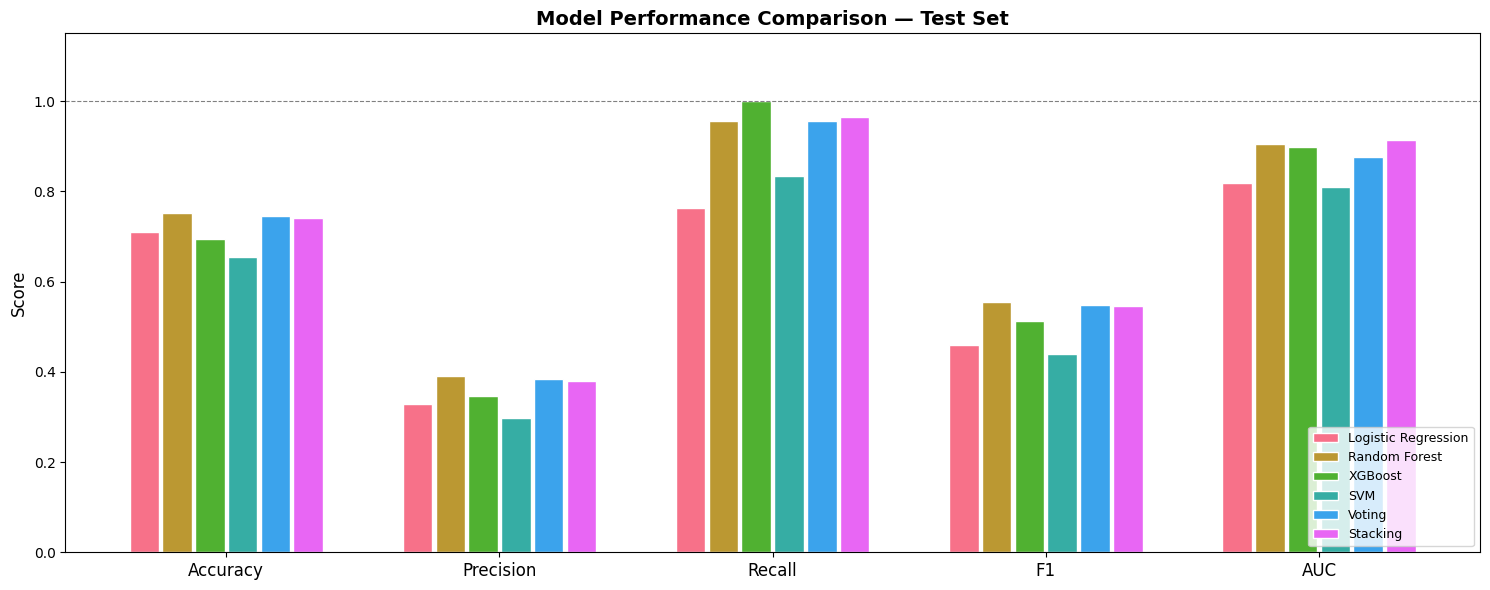

In [41]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC']
x = np.arange(len(metrics))
width = 0.12
palette = sns.color_palette('husl', n_colors=len(results_df))

fig, ax = plt.subplots(figsize=(15, 6))
for i,(model, row) in enumerate(results_df.iterrows()):
    offset = (i - len(results_df)/2) * width + width/2
    ax.bar(x + offset, row[metrics].values, width * 0.9,label=model, color=palette[i], edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=12)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Performance Comparison — Test Set',fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.axhline(1.0, color='gray', linestyle='--', linewidth=0.8)
plt.tight_layout()
plt.show()

#ROC Curves

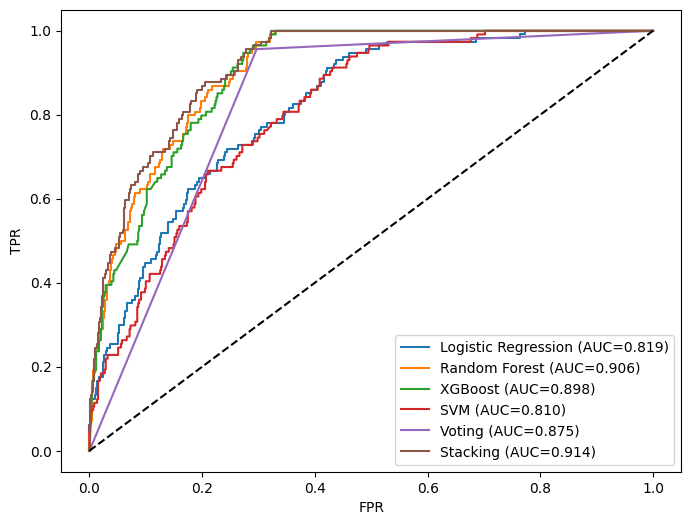

In [42]:
plt.figure(figsize=(8,6))
for model in results_df.index:
    probs = results_df.loc[model, 'probs']
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc_val = results_df.loc[model, 'AUC']
    plt.plot(fpr, tpr, label=f'{model} (AUC={auc_val:.3f})')

plt.plot([0,1],[0,1],'k--')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.legend()
plt.show()

#Confusion Matrices

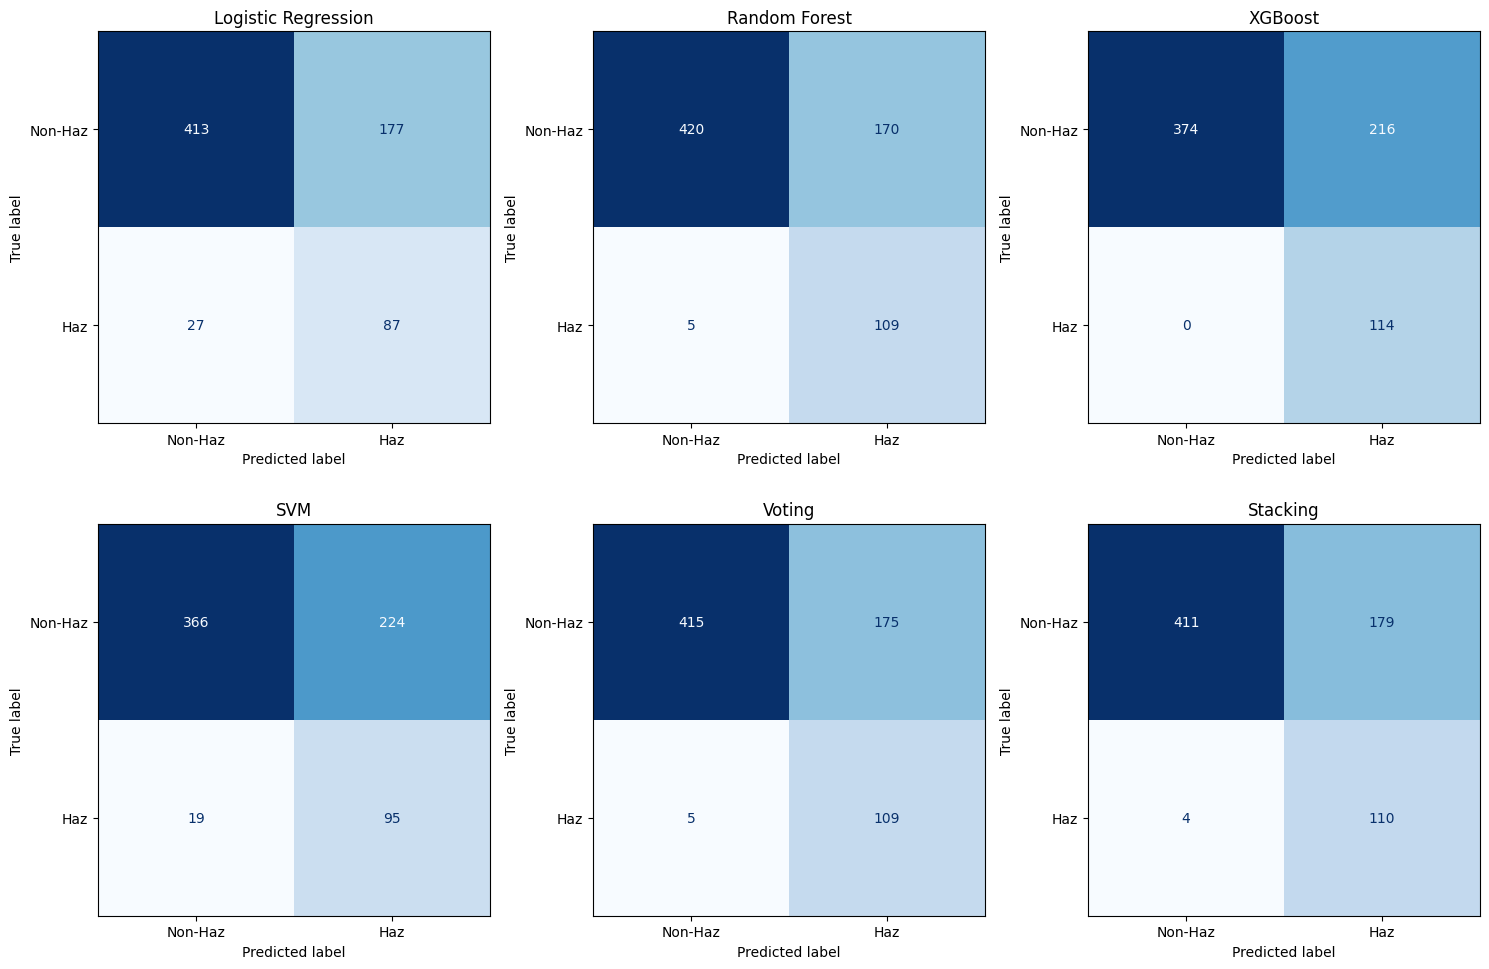

In [43]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()
for i, model in enumerate(results_df.index[:6]):
    y_pred = results_df.loc[model, 'preds']

    # Ensure predictions are binary (0 or 1) for the confusion matrix
    if y_pred.dtype.kind in 'fc':
        y_pred = (y_pred >= 0.5).astype(int)

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Non-Haz', 'Haz'])
    disp.plot(ax=axes[i], colorbar=False, cmap='Blues')
    axes[i].set_title(model)

plt.tight_layout()
plt.show()

#Feature Importance

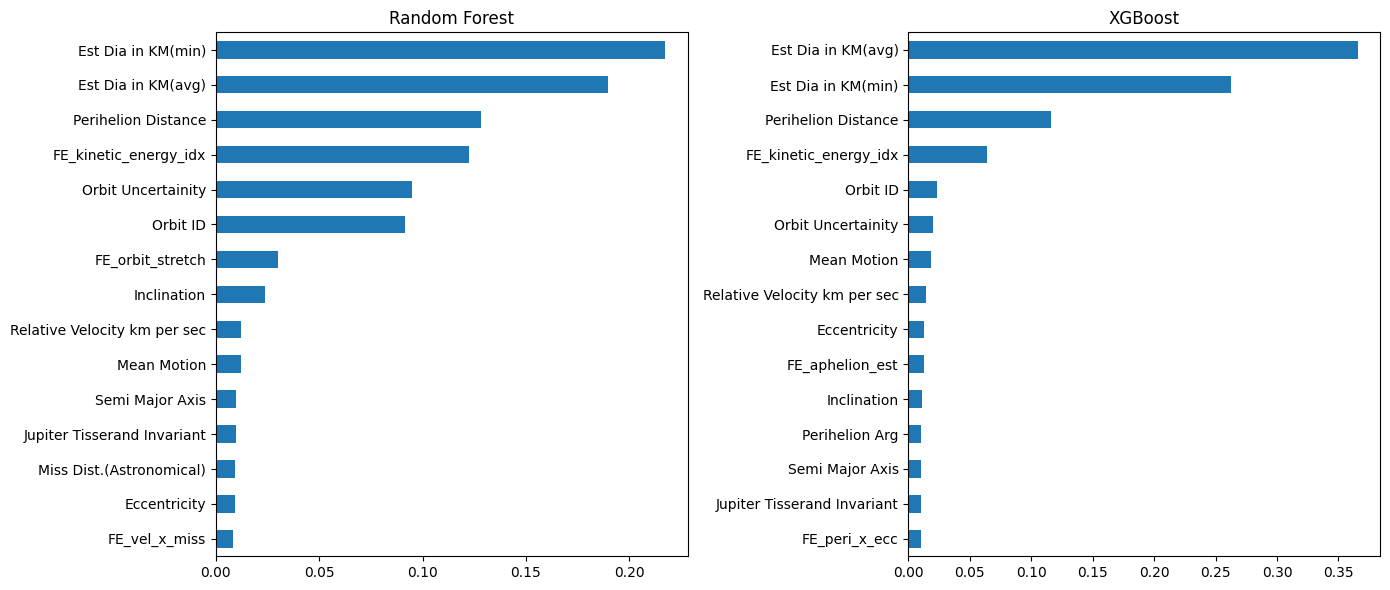

In [44]:
# Feature importance for Random Forest and XGBoost
rf_imp = pd.Series(best_rf.named_steps['clf'].feature_importances_, index=X.columns).sort_values(ascending=False).head(15)
xgb_imp = pd.Series(best_xgb.named_steps['clf'].feature_importances_, index=X.columns).sort_values(ascending=False).head(15)

fig, axes = plt.subplots(1,2, figsize=(14,6))
rf_imp.sort_values().plot(kind='barh', ax=axes[0], title='Random Forest')
xgb_imp.sort_values().plot(kind='barh', ax=axes[1], title='XGBoost')
plt.tight_layout()
plt.show()

#Precision-Recall Curve & Threshold Tuning

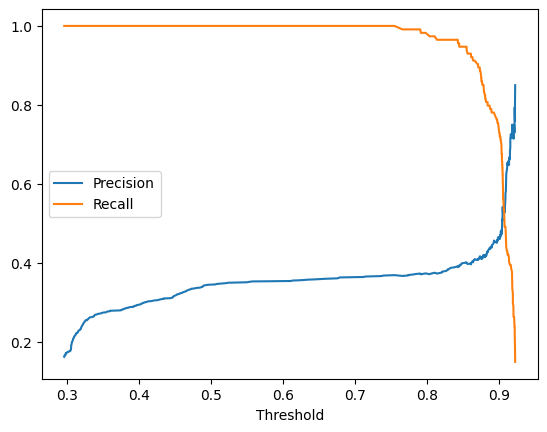

The Optimal Threshold
Threshold for recall 0.95: 0.845


In [45]:
# Threshold tuning for best model (highest recall)
best_model = results_df['Recall'].idxmax()
probs = results_df.loc[best_model, 'probs']
precisions, recalls, thresholds = precision_recall_curve(y_test, probs)

plt.plot(thresholds, precisions[:-1], label='Precision')
plt.plot(thresholds, recalls[:-1], label='Recall')
plt.xlabel('Threshold')
plt.legend()
plt.show()

#search for threshold achieve recall 0.95
target_recall = 0.95
idx = np.argmin(np.abs(recalls - target_recall))
if idx < len(thresholds):

    print("The Optimal Threshold")
    print(f"Threshold for recall {target_recall}: {thresholds[idx]:.3f}")

#Save All Models & Final Summary

In [46]:
# saving models
joblib.dump(best_lr, 'lr_model.pkl')
joblib.dump(best_rf, 'rf_model.pkl')
joblib.dump(best_xgb, 'xgb_model.pkl')
joblib.dump(best_svm, 'svm_model.pkl')
joblib.dump(meta, 'stack_meta.pkl')
print("Models saved.")

Models saved.


In [47]:
results_df.to_csv('results.csv')
print("Done.")

Done.
